In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

In [7]:
matches_2020 = pd.read_csv("atp_matches_2020.csv")
matches_2021 = pd.read_csv("atp_matches_2021.csv")
matches_2022 = pd.read_csv("atp_matches_2022.csv")
matches_2023 = pd.read_csv("atp_matches_2023.csv")
matches_2024 = pd.read_csv("atp_matches_2024.csv")


In [8]:
matches = pd.concat([
    matches_2020,
    matches_2021,
    matches_2022,
    matches_2023,
    matches_2024
], ignore_index=True)

matches.shape

(13174, 49)

In [9]:
winners = matches[[
    "tourney_name",
    "surface",
    "tourney_date",
    "winner_name",
    "winner_ht",
    "winner_age",
    "w_ace",
    "w_df",
    "w_svpt",
    "w_1stIn"
]]

winners = winners.rename(columns={
    "winner_name": "player_name",
    "winner_ht": "height",
    "winner_age": "age",
    "w_ace": "aces",
    "w_df": "double_faults",
    "w_svpt": "service_points",
    "w_1stIn": "first_serve_in"
})

winners["first_serve_pct"] = (
    winners["first_serve_in"] / winners["service_points"]
) * 100

In [10]:
losers = matches[[
    "tourney_name",
    "surface",
    "tourney_date",
    "loser_name",
    "loser_ht",
    "loser_age",
    "l_ace",
    "l_df",
    "l_svpt",
    "l_1stIn"
]]

losers = losers.rename(columns={
    "loser_name": "player_name",
    "loser_ht": "height",
    "loser_age": "age",
    "l_ace": "aces",
    "l_df": "double_faults",
    "l_svpt": "service_points",
    "l_1stIn": "first_serve_in"
})

losers["first_serve_pct"] = (
    losers["first_serve_in"] / losers["service_points"]
) * 100

In [11]:
tennis_data = pd.concat([winners, losers], ignore_index=True)

tennis_data.head()

,tourney_name,surface,tourney_date,player_name,height,age,aces,double_faults,service_points,first_serve_in,first_serve_pct
0,Atp Cup,Hard,20200106,Novak Djokovic,188.0,32.6,12.0,2.0,64.0,49.0,76.562500
1,Atp Cup,Hard,20200106,Roberto Bautista Agut,183.0,31.7,2.0,1.0,59.0,44.0,74.576271
2,Atp Cup,Hard,20200106,Novak Djokovic,188.0,32.6,4.0,5.0,111.0,75.0,67.567568
3,Atp Cup,Hard,20200106,Dusan Lajovic,183.0,29.5,1.0,1.0,67.0,48.0,71.641791
4,Atp Cup,Hard,20200106,Rafael Nadal,185.0,33.5,5.0,3.0,84.0,61.0,72.619048


In [12]:
print("Antes de limpiar:", tennis_data.shape)

tennis_data = tennis_data.dropna(subset=[
    "player_name",
    "height",
    "surface",
    "tourney_date",
    "aces",
    "double_faults",
    "service_points",
    "first_serve_in",
    "first_serve_pct"
])

tennis_data = tennis_data[
    (tennis_data["height"] >= 160) &
    (tennis_data["height"] <= 220) &
    (tennis_data["first_serve_pct"] >= 0) &
    (tennis_data["first_serve_pct"] <= 100)
]

tennis_data = tennis_data.reset_index(drop=True)

print("Después de limpiar:", tennis_data.shape)

Antes de limpiar: (26348, 11)
Después de limpiar: (25149, 11)


In [13]:
tennis_data["height_group"] = pd.cut(
    tennis_data["height"],
    bins=[0, 180, 190, 200, 230],
    labels=["<180", "180-190", "190-200", "200+"]
)

In [14]:
tennis_data[["height", "first_serve_pct", "aces", "double_faults"]].corr()

,height,first_serve_pct,aces,double_faults
height,1.000000,0.027219,0.431338,0.095474
first_serve_pct,0.027219,1.000000,0.024904,-0.283668
aces,0.431338,0.024904,1.000000,0.239575
double_faults,0.095474,-0.283668,0.239575,1.000000


In [15]:
tennis_data.groupby("height_group")[["first_serve_pct", "aces", "double_faults"]].mean()

/tmp/ipykernel_6301/45511806.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tennis_data.groupby("height_group")[["first_serve_pct", "aces", "double_faults"]].mean()


,first_serve_pct,aces,double_faults
height_group,,,
<180,62.608211,3.668430,2.716301
180-190,62.287838,5.318448,2.717013
190-200,62.664991,8.221788,3.090566
200+,65.191767,14.765926,3.885926


In [16]:
os.makedirs("processed", exist_ok=True)
os.makedirs("final", exist_ok=True)

In [17]:
tennis_data.to_csv("processed/tennis_data_clean.csv", index=False)

In [18]:
dim_player = tennis_data[[
    "player_name",
    "height",
    "age",
    "height_group"
]].drop_duplicates().reset_index(drop=True)

dim_player["player_key"] = dim_player.index + 1

In [19]:
dim_surface = tennis_data[["surface"]].drop_duplicates().reset_index(drop=True)

dim_surface["surface_key"] = dim_surface.index + 1

In [20]:
tennis_data["tourney_date"] = pd.to_datetime(
    tennis_data["tourney_date"],
    format="%Y%m%d"
)

dim_time = tennis_data[["tourney_date"]].drop_duplicates().reset_index(drop=True)

dim_time["time_key"] = dim_time.index + 1
dim_time["year"] = dim_time["tourney_date"].dt.year
dim_time["month"] = dim_time["tourney_date"].dt.month
dim_time["day"] = dim_time["tourney_date"].dt.day
dim_time["day_of_week"] = dim_time["tourney_date"].dt.day_name()

In [21]:
dim_tournament = tennis_data[["tourney_name"]].drop_duplicates().reset_index(drop=True)

dim_tournament["tournament_key"] = dim_tournament.index + 1

In [22]:
fact_serve = tennis_data[[
    "player_name",
    "surface",
    "tourney_date",
    "tourney_name",
    "aces",
    "double_faults",
    "service_points",
    "first_serve_in",
    "first_serve_pct"
]]

fact_serve = fact_serve.merge(
    dim_player[["player_name", "player_key"]],
    on="player_name",
    how="left"
)

fact_serve = fact_serve.merge(
    dim_surface,
    on="surface",
    how="left"
)

fact_serve = fact_serve.merge(
    dim_time[["tourney_date", "time_key"]],
    on="tourney_date",
    how="left"
)

fact_serve = fact_serve.merge(
    dim_tournament,
    on="tourney_name",
    how="left"
)

fact_serve = fact_serve[[
    "player_key",
    "surface_key",
    "time_key",
    "tournament_key",
    "aces",
    "double_faults",
    "service_points",
    "first_serve_in",
    "first_serve_pct"
]]

fact_serve.head()

,player_key,surface_key,time_key,tournament_key,aces,double_faults,service_points,first_serve_in,first_serve_pct
0,1,1,1,1,12.0,2.0,64.0,49.0,76.5625
1,201,1,1,1,12.0,2.0,64.0,49.0,76.5625
2,216,1,1,1,12.0,2.0,64.0,49.0,76.5625
3,300,1,1,1,12.0,2.0,64.0,49.0,76.5625
4,419,1,1,1,12.0,2.0,64.0,49.0,76.5625


In [23]:
dim_player.to_csv("final/dim_player.csv", index=False)
dim_surface.to_csv("final/dim_surface.csv", index=False)
dim_time.to_csv("final/dim_time.csv", index=False)
dim_tournament.to_csv("final/dim_tournament.csv", index=False)
fact_serve.to_csv("final/fact_serve.csv", index=False)

In [24]:
print("DIM_PLAYER:", dim_player.shape)
print("DIM_SURFACE:", dim_surface.shape)
print("DIM_TIME:", dim_time.shape)
print("DIM_TOURNAMENT:", dim_tournament.shape)
print("FACT_SERVE:", fact_serve.shape)

DIM_PLAYER: (6509, 5)
DIM_SURFACE: (3, 2)
DIM_TIME: (217, 6)
DIM_TOURNAMENT: (303, 2)
FACT_SERVE: (746436, 9)


In [25]:
conn = sqlite3.connect("tennis_bigdata.db")

dim_player.to_sql("dim_player", conn, if_exists="replace", index=False)
dim_surface.to_sql("dim_surface", conn, if_exists="replace", index=False)
dim_time.to_sql("dim_time", conn, if_exists="replace", index=False)
dim_tournament.to_sql("dim_tournament", conn, if_exists="replace", index=False)
fact_serve.to_sql("fact_serve", conn, if_exists="replace", index=False)

746436

In [26]:
tables = ["dim_player", "dim_surface", "dim_time", "dim_tournament", "fact_serve"]

for table in tables:
    count = pd.read_sql(f"SELECT COUNT(*) AS registros FROM {table}", conn)
    print(table, count["registros"][0])

dim_player 6509
dim_surface 3
dim_time 217
dim_tournament 303
fact_serve 746436


In [27]:
query = """
SELECT
    ds.surface,
    AVG(fs.aces) AS media_aces
FROM fact_serve fs
JOIN dim_surface ds
    ON fs.surface_key = ds.surface_key
GROUP BY ds.surface
ORDER BY media_aces DESC;
"""

pd.read_sql(query, conn)

,surface,media_aces
0,Grass,8.665542
1,Hard,6.971947
2,Clay,4.132830


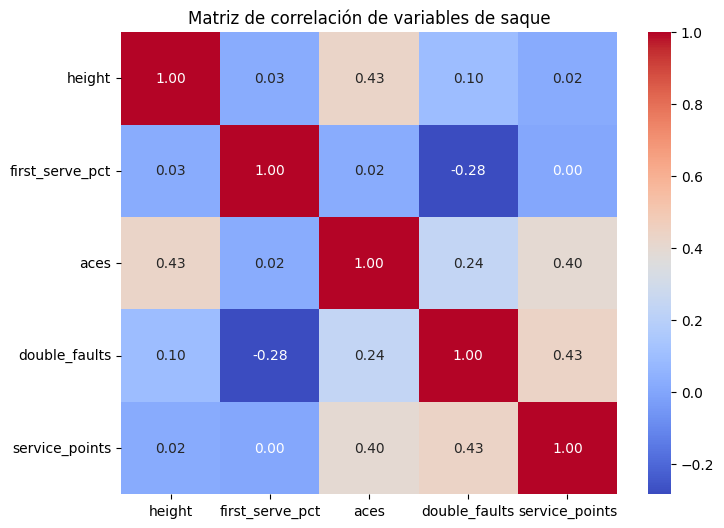

In [28]:
#EDA FINAL Y VISUALIZACIONES
corr = tennis_data[[
    "height",
    "first_serve_pct",
    "aces",
    "double_faults",
    "service_points"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matriz de correlación de variables de saque")
plt.show()


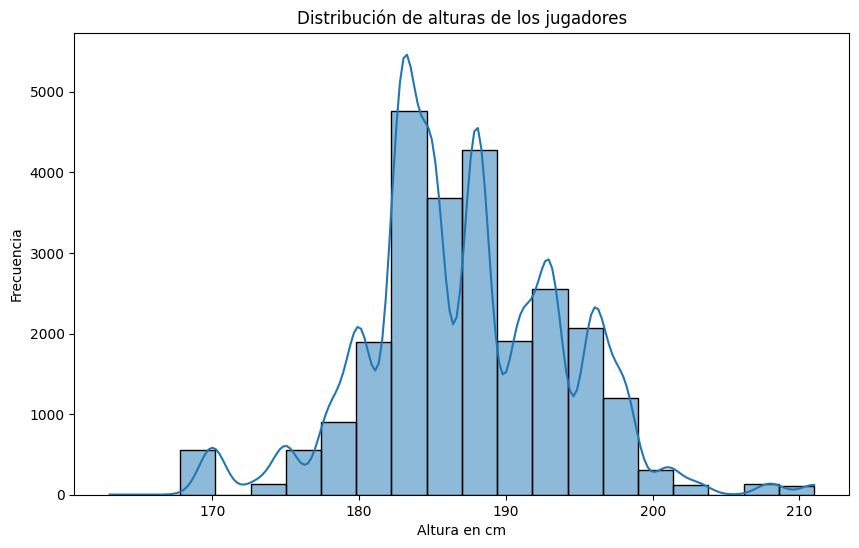

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    tennis_data["height"],
    bins=20,
    kde=True
)

plt.title("Distribución de alturas de los jugadores")
plt.xlabel("Altura en cm")
plt.ylabel("Frecuencia")

plt.show()

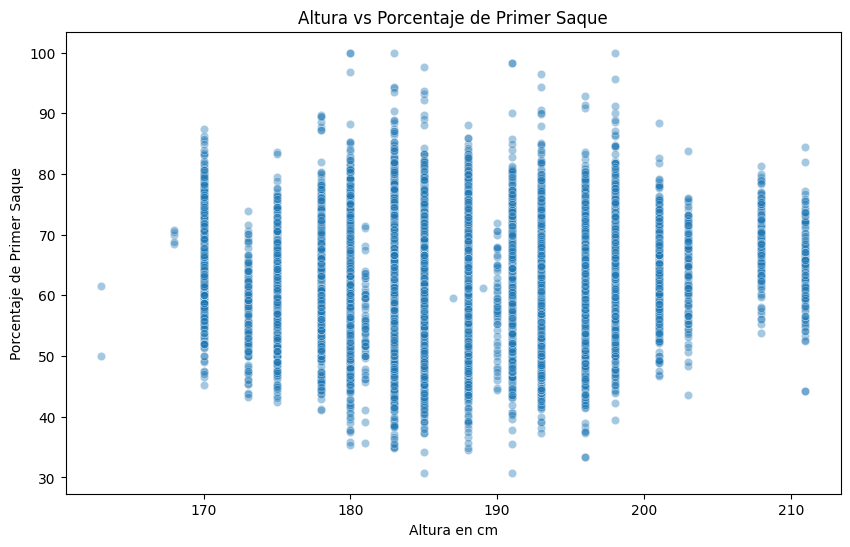

In [30]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=tennis_data,
    x="height",
    y="first_serve_pct",
    alpha=0.4
)

plt.title("Altura vs Porcentaje de Primer Saque")
plt.xlabel("Altura en cm")
plt.ylabel("Porcentaje de Primer Saque")

plt.show()

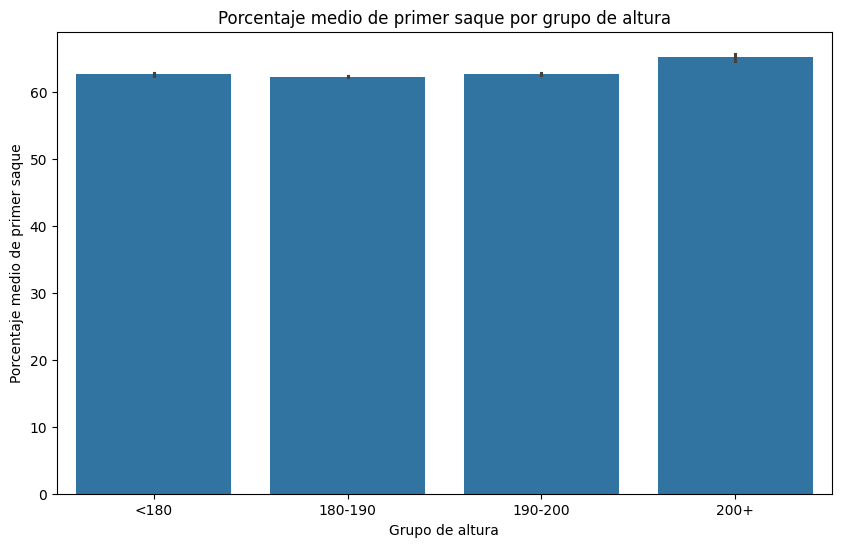

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=tennis_data,
    x="height_group",
    y="first_serve_pct",
    order=["<180", "180-190", "190-200", "200+"]
)

plt.title("Porcentaje medio de primer saque por grupo de altura")
plt.xlabel("Grupo de altura")
plt.ylabel("Porcentaje medio de primer saque")

plt.show()

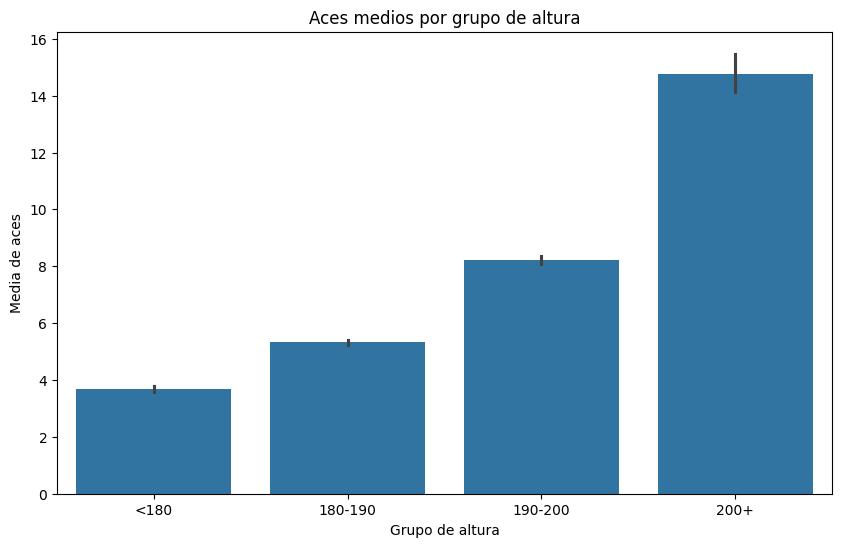

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=tennis_data,
    x="height_group",
    y="aces",
    order=["<180", "180-190", "190-200", "200+"]
)

plt.title("Aces medios por grupo de altura")
plt.xlabel("Grupo de altura")
plt.ylabel("Media de aces")

plt.show()

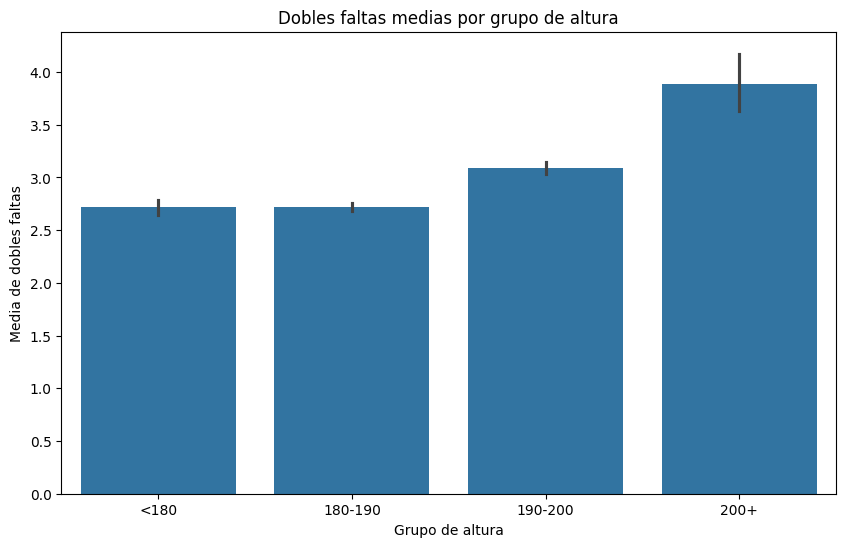

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=tennis_data,
    x="height_group",
    y="double_faults",
    order=["<180", "180-190", "190-200", "200+"]
)

plt.title("Dobles faltas medias por grupo de altura")
plt.xlabel("Grupo de altura")
plt.ylabel("Media de dobles faltas")

plt.show()

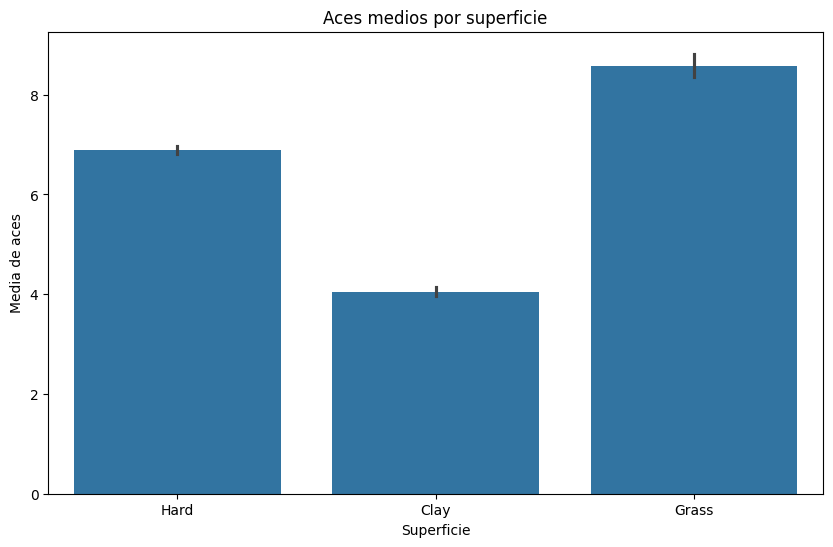

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=tennis_data,
    x="surface",
    y="aces"
)

plt.title("Aces medios por superficie")
plt.xlabel("Superficie")
plt.ylabel("Media de aces")

plt.show()

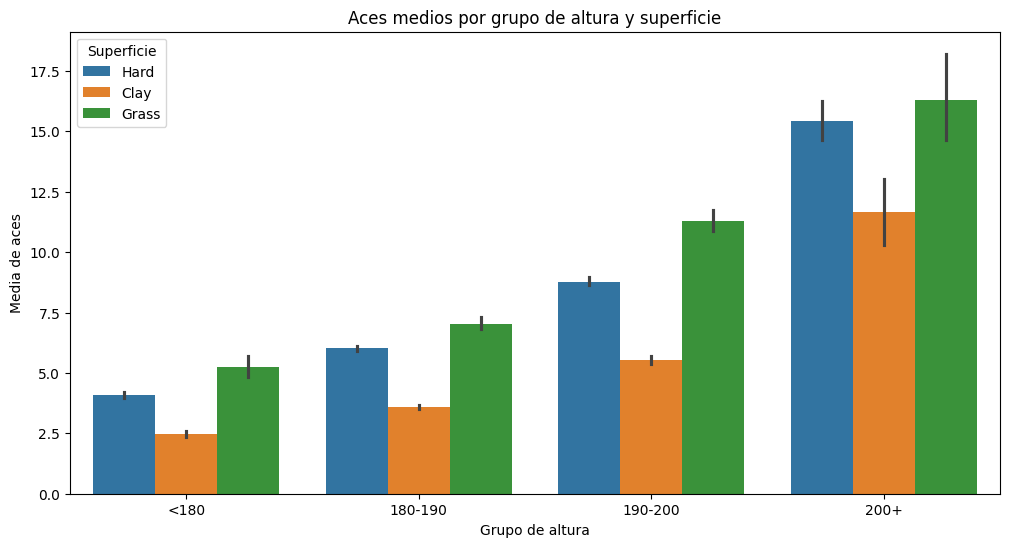

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=tennis_data,
    x="height_group",
    y="aces",
    hue="surface",
    order=["<180", "180-190", "190-200", "200+"]
)

plt.title("Aces medios por grupo de altura y superficie")
plt.xlabel("Grupo de altura")
plt.ylabel("Media de aces")
plt.legend(title="Superficie")

plt.show()

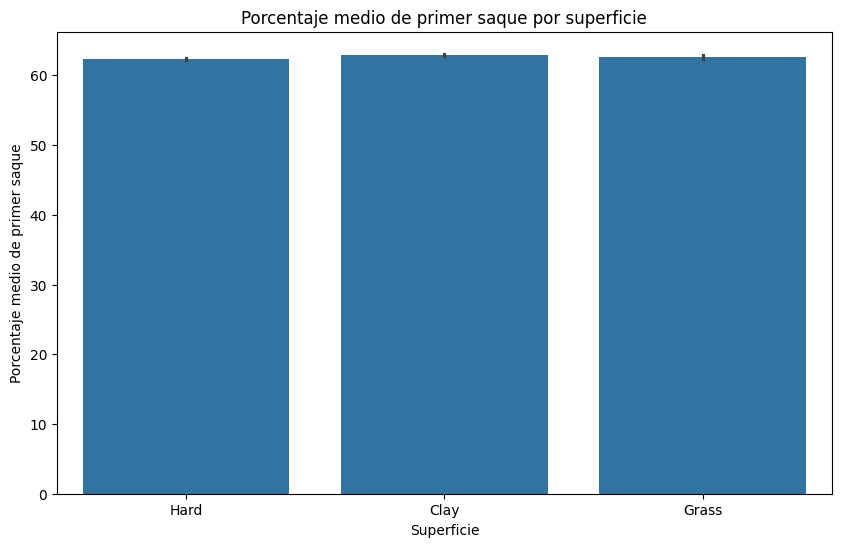

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=tennis_data,
    x="surface",
    y="first_serve_pct"
)

plt.title("Porcentaje medio de primer saque por superficie")
plt.xlabel("Superficie")
plt.ylabel("Porcentaje medio de primer saque")

plt.show()

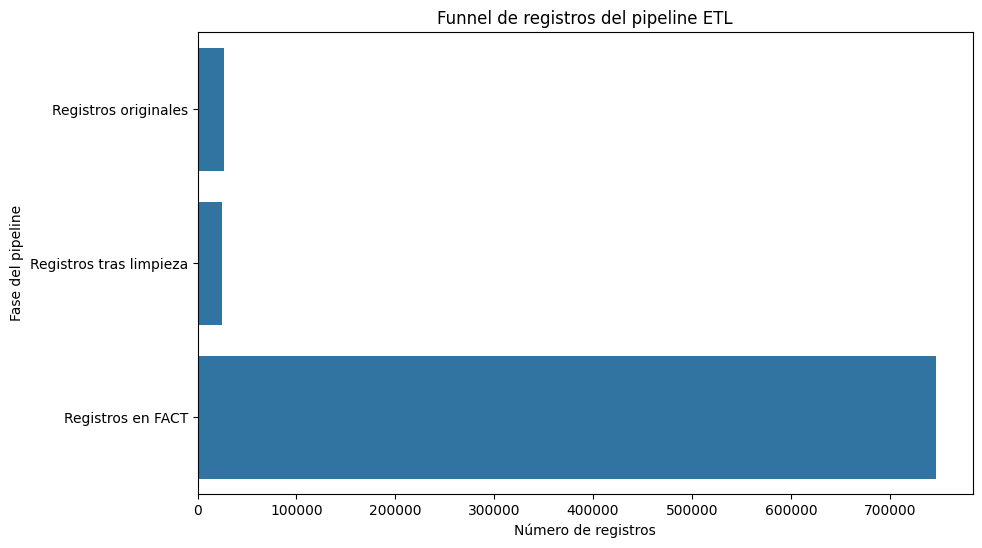

In [37]:
pipeline_counts = {
    "Registros originales": len(winners) + len(losers),
    "Registros tras limpieza": len(tennis_data),
    "Registros en FACT": len(fact_serve)
}

plt.figure(figsize=(10,6))

sns.barplot(
    x=list(pipeline_counts.values()),
    y=list(pipeline_counts.keys())
)

plt.title("Funnel de registros del pipeline ETL")
plt.xlabel("Número de registros")
plt.ylabel("Fase del pipeline")

plt.show()